If 'initial' is true, we've giving p1=muv p2=muq and we're solving for v1=theta_0 v2=theta_d_0 v3=muc
Otherwise,  we're giving p1=theta_0 p2=theta_d_0 p3=muc and we're solving for v1=muv v2=muq

In [261]:
import time
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import taichi as ti
ti.init(arch=ti.gpu, default_fp=ti.f32)

[Taichi] Starting on arch=cuda


Getting the data to compare to.

In [262]:
FILE_PATH = input("File path to data:").strip()
data = np.genfromtxt(FILE_PATH, delimiter=",", skip_header=True) #../../tracking/data/test.csv
BIG_ARM = "Big" in FILE_PATH

# data = np.genfromtxt("../../tracking/data/BigArm1.csv", delimiter=',', skip_header=True)
# BIG_ARM = True

# data = data[:13920, :]
data[:, 9] -= np.mean(data[:, 9])


num_time_datapoints = data.shape[0]

# initial angle
init = data[0, 9]
init_err = data[0, 11]
# v1_range = (init - 5*init_err, init + 5*init_err) # multiplying the error range by 5 for safety

# initial velocity
v_init = (data[1, 9] - data[0, 9]) / (data[1, 0] - data[0, 0])
v_init_err = np.hypot(data[1, 11] / (data[1, 0] - data[0, 0]), data[0, 11] / (data[1, 0] - data[0, 0]))
# v2_range = (v_init - 2*v_init_err, v_init + 2*v_init_err) #the multiplication by 5 may be overkill here

# friction
# muc_guess = 0.1
# muc_guess_err = 0.1
# v3_range = (muc_guess-muc_guess_err, muc_guess+muc_guess_err)

In [263]:
def normed_pos_from_angle(angle, angle_err):
    return (np.sin(angle), -np.cos(angle)), (abs(angle_err*np.cos(angle)), abs(angle_err*np.sin(angle)))

In [264]:
def pendulum_energy(theta, theta_d, I, m, g, rcm):
    T = 0.5 * I[0] * theta_d[0]**2
    V = -m[0]*g[0]*rcm[0]*np.cos(theta[0])

    T_err = np.hypot(I[1] * 0.5*theta_d[0]**2, theta_d[1] * I[0] * theta_d[0])
    V_err = np.sqrt(
        (m[1] * g[0]*rcm[0]*np.cos(theta[0]))**2 +
        (g[1] * m[0]*rcm[0]*np.cos(theta[0]))**2 +
        (rcm[1] * m[0]*g[0]*np.cos(theta[0]))**2 +
        (theta[1] * m[0]*g[0]*rcm[0]*np.sin(theta[0]))**2
    )

    return T + V, np.hypot(T_err, V_err)

Setting up the number of simulations happening at the same time, and for how long they should run.

In [265]:
num_sims = (500, 500, 500)

# in seconds, running the simulation for as long as the data goes
sim_time = data[-1, 0]

In [266]:
sims = ti.Vector.field(2, ti.f32, shape=num_sims)
costs = ti.field(ti.f32, shape=num_sims)

Helper Taichi functions

In [267]:
@ti.pyfunc
def map_range(value: float, min_in: float, max_in: float, min_out: float, max_out: float) -> float:
    return (value - min_in) / (max_in - min_in) * (max_out - min_out) + min_out

Setting up initial conditions of the pendulums.

In [268]:
@ti.kernel
def setup(initial: ti.int32, p1: ti.f32, p2: ti.f32, p3: ti.f32, v1_range: ti.math.vec2, v2_range: ti.math.vec2, v3_range: ti.math.vec2):
    for i, j, k in sims:
        if initial:
            theta_0 = map_range(i, 0, num_sims[0], v1_range[0], v1_range[1])
            theta_d_0 = map_range(j, 0, num_sims[1], v2_range[0], v2_range[1])

            sims[i, j, k] = ti.Vector([theta_0, theta_d_0])
            costs[i, j, k] = 0
        else:
            theta_0 = p1
            theta_d_0 = p2

            sims[i, j, k] = ti.Vector([theta_0, theta_d_0])
            costs[i, j, k] = 0

Defining the function $f$ in $y' = f(y)$

In [269]:
# taichi versions

@ti.pyfunc
def get_angular_acceleration(y: ti.math.vec2, I: float, rcm: float, m: float, g: float, r_inner: float, muv: float, muq: float, muc: float) -> float:
    return -(y[1]*muv + y[1]*muq*abs(y[1]) + r_inner*muc*ti.tanh(1000*y[1])*ti.abs(m*(y[1]**2*rcm + g*ti.cos(y[0]))) + rcm*g*m*ti.sin(y[0]))/I


@ti.pyfunc
def f(y: ti.math.vec2, I: float, rcm: float, m: float, g: float, r_inner: float, muv: float, muq: float, muc: float) -> ti.math.vec2:
    return ti.Vector([
        y[1],
        get_angular_acceleration(y, I, rcm, m, g, r_inner, muv, muq, muc)
    ])

A simulation step.

In [270]:
@ti.kernel
def update(step: float, big_arm: ti.int32, initial: ti.int32, p1: ti.f32, p2: ti.f32, p3: ti.f32, v1_range: ti.math.vec2, v2_range: ti.math.vec2, v3_range: ti.math.vec2):
    for i, j, k in sims:

        # defaults to small arm parameters
        m = 86e-3 
        g = 9.81
        rcm = 9.225e-2
        I = 0.00103
        r_inner = 8e-3

        if big_arm:
            m = 108.5e-3
            rcm = 11.7e-2
            I = 0.00216

        muv = 0.0
        muq = 0.0
        muc = 0.0

        if initial:
            muv = p1
            muq = p2
            muc = map_range(k, 0, num_sims[2], v3_range[0], v3_range[1])
        else:
            muv = map_range(i, 0, num_sims[0], v1_range[0], v1_range[1])
            muq = map_range(j, 0, num_sims[1], v2_range[0], v2_range[1])
            muc = map_range(k, 0, num_sims[2], v3_range[0], v3_range[1])

        oldValue = sims[i, j, k]
        k1 = step * f(oldValue, I, rcm, m, g, r_inner, muv, muq, muc)
        k2 = step * f(oldValue + k1/2, I, rcm, m, g, r_inner, muv, muq, muc)
        k3 = step * f(oldValue + k2/2, I, rcm, m, g, r_inner, muv, muq, muc)
        k4 = step * f(oldValue + k3, I, rcm, m, g, r_inner, muv, muq, muc)

        newValue = oldValue + k1/6 + k2/3 + k3/3 + k4/6
        sims[i, j, k] = newValue

Determining the $\chi^2$ contribution for this data point. This kernel runs when a data point lies between this simulation step and the next (in time). A RK4 step is then performed to get the simulation to the time at which the data point was recorded. Finally, the position at the end of the pivot is calculated for the data point and the simulated point, and their squared distances are divided by the data uncertainty and added to the running $\chi^2$ value. This is all done for each simulation simultaneously.

$\chi^2 = \sum^{N}_{i=1} \left[ \frac{y_i - f(x_i)}{\alpha_i}  \right]^2$

In [271]:
@ti.func
def get_chi_squared_term(prediction: ti.f32, data: ti.f32, data_error: ti.f32) -> float:
    term_sqrt = (data - prediction) / data_error
    return term_sqrt*term_sqrt

@ti.kernel
def add_cost(energy: ti.i32, big_arm: ti.i32, data: ti.f32, data_error: ti.f32):
    for i, j, k in sims:        
        val = sims[i, j, k]
        theta = val[0]

        this_cost = 0.0

        if energy:
            theta_d = val[1]
            E = 0.0
            if big_arm:
                T = 0.5 * 0.00216 * theta_d*theta_d
                V = -108.5e-3*9.81*11.7e-2*ti.cos(theta)
                E = T + V
            else:
                T = 0.5 * 0.00103 * theta_d*theta_d
                V = -86e-3*9.81*9.225e-2*ti.cos(theta)
                E = T + V
            this_cost = get_chi_squared_term(E, data, data_error)

        else:
            this_cost = get_chi_squared_term(theta, data, data_error)

        costs[i, j, k] += this_cost

Visualizing the result.

In [272]:
pixels = ti.Vector.field(3, ti.f32, shape=(num_sims[0], num_sims[1]))


@ti.func
def colormap(val: float) -> ti.math.vec3:
    val = 1-val
    x = ti.max(0.0, ti.min(1.0, val))

    # A simplified Magma approximation
    r = 1.0 - ti.pow(1.0 - x, 3.0)
    g = ti.pow(x, 3.0) + 0.2 * ti.sin(3.14 * x)
    b = 0.2 + 0.6 * ti.pow(x, 5.0)

    return ti.Vector([ti.math.clamp(r, 0, 1),
                      ti.math.clamp(g, 0, 1),
                      ti.math.clamp(b, 0, 1)])


@ti.kernel
def draw(num_costs_calculated: int):
    for i, j in pixels:
        # pixels[i, j] = ti.Vector([sims[i, j][0], sims[i, j][1]/10 + 0.5, 0])
        costs_remapped = 0.14*ti.math.log(costs[i, j, ti.cast(num_sims[2]/2, ti.int32)]/num_costs_calculated + 1)
        # costs_remapped = 1*ti.math.log(costs[i, j, ti.cast(num_sims[2]/2, ti.int32)]/num_costs_calculated + 1)
        pixels[i, j] = colormap(costs_remapped)

Running the simulation loop.

In [ ]:
# at the end of this function, the costs buffer is updated
def get_costs(visualize, initial, big_arm, time_limit, p1, p2, p3, v1_range, v2_range, v3_range):
    print("running get costs with ", p1, p2, p3, v1_range, v2_range, v3_range)

    if visualize:
        window = ti.ui.Window("Visualization", (800, 800))
        canvas = window.get_canvas()

    t = data[0, 0]
    index_in_data = 0

    setup(initial, p1, p2, p3, v1_range, v2_range, v3_range)

    while True:
        if visualize and not window.running:
            break

        this_data_entry = data[index_in_data, :]

        if initial:
            add_cost(False, big_arm, this_data_entry[9], this_data_entry[11])

        else:
            total_energy = data[index_in_data, 13] + data[index_in_data, 15]
            total_energy_err = np.hypot(data[index_in_data, 14], data[index_in_data, 16])
            add_cost(True, big_arm, total_energy, total_energy_err)

        if index_in_data == num_time_datapoints-2 or t >= data[0, 0] + time_limit: break
        # otherwise, move on to the next simulations step

        # since there are so many data points recorded, im skipping a bunch
        while index_in_data < num_time_datapoints-2 and data[index_in_data, 0] - t < 0.025:
            index_in_data = index_in_data + 1

        time_step = data[index_in_data, 0] - t
        t = data[index_in_data, 0]

        update(time_step, big_arm, initial, p1, p2, p3, v1_range, v2_range, v3_range)

        if visualize:
            draw(index_in_data)
            if (t % (1/60)) < ((t - time_step) % (1/60)):
                canvas.set_image(pixels)
                window.show()
                # time.sleep(1/30)

    if visualize: window.destroy()

Now that we the grid of $\chi^2$ values, we need to find the element with the lowest $\chi^2$ and determine which parameters it represents.

In [274]:
# returns the variable values which minimize chi2, and the chi2
def get_optimal(v1_range, v2_range, v3_range):
    costs_np = costs.to_numpy()
    np.nan_to_num(costs_np, False, np.inf)
    min_chi2 = np.min(costs_np)
    min_indices = np.unravel_index(costs_np.argmin(), num_sims)

    var_1_best = map_range(
        min_indices[0], 0, num_sims[0], v1_range[0], v1_range[1]
    )
    var_2_best = map_range(
        min_indices[1], 0, num_sims[1], v2_range[0], v2_range[1]
    )
    var_3_best = map_range(
        min_indices[2], 0, num_sims[2], v3_range[0], v3_range[1]
    )

    return var_1_best, var_2_best, var_3_best, min_chi2

There's a big possibility that the original ranges given are way too big and almost all of the computation is useless. This crops the simulated range down to only where it's interesting. To do this, simulate with the initial range and find the $\chi^2_{\text{min}}$, then crop out the regions where $\chi^2 > \frac{3}{2}\chi^2_\text{min}$.

In [275]:
def crop_ranges(initial, big_arm, time_limit, p1, p2, p3, v1_range, v2_range, v3_range):
    # initial costs calculation:
    get_costs(True, initial, big_arm, time_limit, p1, p2, p3, v1_range, v2_range, v3_range)
    np_costs = costs.to_numpy()
    min_cost = np.min(np_costs)
    cost_threshold = 1.5 * min_cost

    cut_start = [0, 0, 0]
    cut_end = [num_sims[0], num_sims[1], num_sims[2]]

    for i in range(num_sims[0]):
        this_slice_min = np.min(np_costs[i, :, :])
        if (this_slice_min < cost_threshold):
            cut_start[0] = i
            break

    for j in range(num_sims[1]):
        this_slice_min = np.min(np_costs[:, j, :])
        if (this_slice_min < cost_threshold):
            cut_start[1] = j
            break

    for k in range(num_sims[2]):
        this_slice_min = np.min(np_costs[:, :, k])
        if (this_slice_min < cost_threshold):
            cut_start[2] = k
            break


    for i in range(cut_end[0]-1, cut_start[0], -1):
        this_slice_min = np.min(np_costs[i, :, :])
        if (this_slice_min < cost_threshold):
            cut_end[0] = i
            break

    for j in range(cut_end[1]-1, cut_start[1], -1):
        this_slice_min = np.min(np_costs[:, j, :])
        if (this_slice_min < cost_threshold):
            cut_end[1] = j
            break

    for k in range(cut_end[2]-1, cut_start[2], -1):
        this_slice_min = np.min(np_costs[:, :, k])
        if (this_slice_min < cost_threshold):
            cut_end[2] = k
            break

    var_1_range_cut = (
        map_range(cut_start[0], 0, num_sims[0], v1_range[0], v1_range[1]),
        map_range(cut_end[0], 0, num_sims[0], v1_range[0], v1_range[1])
    )
    var_2_range_cut = (
        map_range(cut_start[1], 0, num_sims[1], v2_range[0], v2_range[1]),
        map_range(cut_end[1], 0, num_sims[1], v2_range[0], v2_range[1])
    )
    var_3_range_cut = (
        map_range(cut_start[2], 0, num_sims[2], v3_range[0], v3_range[1]),
        map_range(cut_end[2], 0, num_sims[2], v3_range[0], v3_range[1])
    )

    print("Before: ", v1_range, v2_range, v3_range, "\nAfter: ", var_1_range_cut, var_2_range_cut, var_3_range_cut)

    return var_1_range_cut, var_2_range_cut, var_3_range_cut

# First, we do an 'initial' run, finding approximate initial angle and angular velocity values and also muc because we can

In [276]:
# returns a best estimate for theta_0 and theta_0_d as tuples with their uncertainties
def initial_run(narrow_steps, repeat_measurements, time_limit, theta_0_range, theta_0_d_range, muc, muv, muq):
    v1_range = theta_0_range
    v2_range = theta_0_d_range
    v3_range = (0, 0)
    for i in range(narrow_steps):
        v1_range, v2_range, v3_range = crop_ranges(i==0, BIG_ARM, time_limit, muv, muq, muc, v1_range, v2_range, v3_range)

    # now that we have tighter bounds on the unknowns, we can try to find the minima
    v1 = []; v2 = []; v3 = []

    for i in range(repeat_measurements): # turn this to something big enough to get a gaussian distribution

        v1_scale = 0.1*(v1_range[1]-v1_range[0])
        this_v1_range = (
            np.random.normal(v1_range[0], v1_scale),
            np.random.normal(v1_range[1], v1_scale)
        )

        v2_scale = 0.1*(v2_range[1]-v2_range[0])
        this_v2_range = (
            np.random.normal(v2_range[0], v2_scale),
            np.random.normal(v2_range[1], v2_scale)
        )

        v3_scale = 0.1*(v3_range[1]-v3_range[0])
        this_v3_range = (
            np.random.normal(v3_range[0], v3_scale),
            np.random.normal(v3_range[1], v3_scale)
        )

        get_costs(i==0, True, BIG_ARM, time_limit, muv, muq, muc, this_v1_range, this_v2_range, this_v3_range)

        var_1_best, var_2_best, var_3_best, min_chi2 = get_optimal(this_v1_range, this_v2_range, this_v3_range)

        v1.append(var_1_best); v2.append(var_2_best); v3.append(var_3_best)

        degrees_of_freedom = num_time_datapoints-3 #-3 because there are three parameters being fit
        p_val = stats.chi2.sf(min_chi2, degrees_of_freedom)

        print(min_chi2, degrees_of_freedom)

    v1 = np.array(v1); v2 = np.array(v2); v3 = np.array(v3)

    return (np.mean(v1), np.std(v1, ddof=1)/np.sqrt(repeat_measurements)), (np.mean(v2), np.std(v2, ddof=1)/np.sqrt(repeat_measurements))

# Then, we do a 'friction' run, where we take the initial parameters and muc as constant and try to find muv and muq

In [277]:
# returns a best estimate for muv, muq, muc, as tuples with their uncertainties
def friction_run(narrow_steps, repeat_measurements, muc_range, muv_range, muq_range, theta_0, theta_d_0):
    v1_range = muv_range
    v2_range = muq_range
    v3_range = muc_range
    for i in range(narrow_steps):
        v1_range, v2_range, v3_range = crop_ranges(False, BIG_ARM, np.inf, theta_0, theta_d_0, 0, v1_range, v2_range, v3_range)

    # now that we have tighter bounds on the unknowns, we can try to find the minima
    v1 = []; v2 = []; v3 = []

    for i in range(repeat_measurements): # turn this to something big enough to get a gaussian distribution

        v1_scale = 0.1*(v1_range[1]-v1_range[0])
        this_v1_range = (
            max(np.random.normal(v1_range[0], v1_scale), 0),
            np.random.normal(v1_range[1], v1_scale)
        )

        v2_scale = 0.1*(v2_range[1]-v2_range[0])
        this_v2_range = (
            max(np.random.normal(v2_range[0], v2_scale), 0),
            np.random.normal(v2_range[1], v2_scale)
        )

        v3_scale = 0.1*(v3_range[1]-v3_range[0])
        this_v3_range = (
            max(np.random.normal(v3_range[0], v3_scale), 0),
            np.random.normal(v3_range[1], v3_scale)
        )
        
        get_costs(i==0, False, BIG_ARM, np.inf, theta_0, theta_d_0, 0, this_v1_range, this_v2_range, this_v3_range)

        var_1_best, var_2_best, var_3_best, min_chi2 = get_optimal(this_v1_range, this_v2_range, this_v3_range)

        v1.append(var_1_best); v2.append(var_2_best); v3.append(var_3_best)

        degrees_of_freedom = num_time_datapoints-3 #-3 because there are three parameters being fit
        p_val = stats.chi2.sf(min_chi2, degrees_of_freedom)

        print(min_chi2, degrees_of_freedom)

    v1 = np.array(v1); v2 = np.array(v2); v3 = np.array(v3)

    return (np.mean(v1), np.std(v1, ddof=1)/np.sqrt(repeat_measurements)), (np.mean(v2), np.std(v2, ddof=1)/np.sqrt(repeat_measurements)), (np.mean(v3), np.std(v3, ddof=1)/np.sqrt(repeat_measurements))

# Visualizing the optimal parameters as a sanity check

In [278]:
def visualize(theta_0, theta_d_0, muc, muv, muq):
    if (BIG_ARM):
        m_sim = 108.5e-3
        g_sim = 9.81
        rcm_sim = 11.7e-2
        I_sim = 0.00216
        r_inner_sim = 8e-3
    else:
        m_sim = 86e-3
        g_sim = 9.81
        rcm_sim = 9.225e-2
        I_sim = 0.00103
        r_inner_sim = 8e-3

    y = np.array([theta_0, theta_d_0])
    t = 0

    h = 0.025

    past_positions = np.array(y)

    for i in np.arange(0, sim_time, h):
        k1 = h*f(y, I_sim, rcm_sim, m_sim, g_sim, r_inner_sim, muv, muq, muc)
        k2 = h*f(y + k1/2, I_sim, rcm_sim, m_sim, g_sim, r_inner_sim, muv, muq, muc)
        k3 = h*f(y + k2/2, I_sim, rcm_sim, m_sim, g_sim, r_inner_sim, muv, muq, muc)
        k4 = h*f(y + k3, I_sim, rcm_sim, m_sim, g_sim, r_inner_sim, muv, muq, muc)

        y = y + k1/6 + k2/3 + k3/3 + k4/6
        past_positions = np.vstack([past_positions, y])

    theta_sim = past_positions[:-1, 0]
    t_sim = np.arange(0, sim_time, h)

    plt.plot(data[:, 0] - data[0, 0], data[:, 9])
    plt.plot(t_sim, theta_sim)

# Now, to actually run the code

In [279]:
theta_0, theta_d_0 = initial_run(1, 10, 1, (init - 12*init_err, init + 12*init_err), (v_init - 2*v_init_err, v_init + 2*v_init_err), 0, 0, 0)
# print(theta_0, theta_d_0)

running get costs with  0 0 0 (1.7261965321633286, 2.6690125321633285) (-28.17023586834978, 24.92712209589475) (0, 0)
Before:  (1.7261965321633286, 2.6690125321633285) (-28.17023586834978, 24.92712209589475) (0, 0) 
After:  (2.0693815561633286, 2.1184079881633284) (-1.833946318084493, -1.0905833065850707) (0.0, 0.0)
running get costs with  0 0 0 (2.0708504117947735, 2.1179454596413176) (-1.9099408107311326, -0.9649818757491169) (0.0, 0.0)
79.33352 14128
running get costs with  0 0 0 (2.0684779185530715, 2.119244499460309) (-1.823457465596556, -0.942027735378208) (0.0, 0.0)
79.33327 14128
running get costs with  0 0 0 (2.0723045361454226, 2.1091525253134917) (-1.7310314622975043, -1.095391277759867) (0.0, 0.0)
79.33362 14128
running get costs with  0 0 0 (2.07172343590598, 2.116492954587095) (-1.8032765997054383, -1.170166192674128) (0.0, 0.0)
79.33337 14128
running get costs with  0 0 0 (2.0744929134368895, 2.120394897528112) (-1.8567465648578967, -1.2980366290578695) (0.0, 0.0)
79.333

In [280]:
# visualize(theta_0[0], theta_d_0[0], 0, 0 ,0)
# plt.xlim(0, 2)

In [281]:
muv, muq, muc = friction_run(1, 5, (0, 0.2), (0, 0.001), (0, 5e-5), theta_0[0], theta_d_0[0])
# print(init, v_init, muc, muv, muq)

running get costs with  2.0957112569469585 -1.497473661419825 0 (0, 0.001) (0, 5e-05) (0, 0.2)
Before:  (0, 0.001) (0, 5e-05) (0, 0.2) 
After:  (0.0, 2.4e-05) (0.0, 1.6000000000000001e-06) (0.0364, 0.05560000000000001)
running get costs with  2.0957112569469585 -1.497473661419825 0 (0, 2.1335356083579802e-05) (0, 1.5578936530032483e-06) (0.03364674888547462, 0.05548028038867353)
209.61722 14128
running get costs with  2.0957112569469585 -1.497473661419825 0 (0, 2.433205648465599e-05) (0, 1.752626521733826e-06) (0.03680955682152127, 0.05779586111112291)
209.61855 14128
running get costs with  2.0957112569469585 -1.497473661419825 0 (0, 2.0586012753308252e-05) (0, 1.8902618272006812e-06) (0.034116984549692794, 0.053880534169368166)
209.61745 14128
running get costs with  2.0957112569469585 -1.497473661419825 0 (0, 2.436941309671217e-05) (0, 1.939247106329555e-06) (0.03531700402983692, 0.05484408439470136)
209.618 14128
running get costs with  2.0957112569469585 -1.497473661419825 0 (0, 2

(0.04398722159376071, 1.1176709420192617e-05) (0.0, 0.0) (1.3801564626721553e-05, 1.7433082041999948e-08)


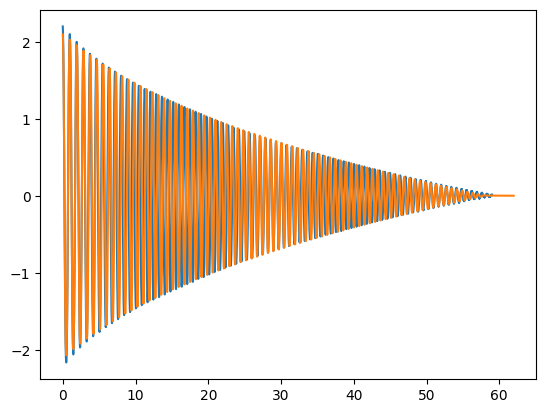

In [282]:
# visualize(theta_0[0], theta_d_0[0], muc[0], 0, 0)
visualize(theta_0[0], theta_d_0[0], muc[0], muv[0], muq[0])
# plt.xlim(0, 10)

print(muc, muq, muv)

In [283]:
FILE_PATH

'../../tracking/data/SmallArm4.csv'